# Multi-Asset ETF Forecasting with Deep Learning

This notebook compares MLP, CNN–GAF, and LSTM models for forecasting 25-day ahead returns across five ETFs (SPY, TLT, SHY, GLD, and DBO). Single-output and multi-output architectures are evaluated, then the multi-output forecasts are turned into a long/short allocation strategy and compared with an equal-weight buy-and-hold benchmark.


### Import libraries which we would need in this project

In [1]:
!pip install pyts

In [36]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import tensorflow as tf

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from pyts.image import GramianAngularField

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, LSTM

sns.set_theme(style="whitegrid")


# Step 1: Data Gathering & EDA
ETFs: SPY, TLT, SHY, GLD, DBO

### 1.1 Download data

In [3]:
TICKERS = ["SPY", "TLT", "SHY", "GLD", "DBO"]
START = "2007-01-01"   # common start: after DBO inception (Jan 2007)
END = "2022-12-30"     # matches assignment's test period end

raw = yf.download(TICKERS, start=START, end=END, progress=False, auto_adjust=True)
prices = raw["Close"].dropna()  # aligned close prices, common trading days only

print("Data shape:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print(prices.isna().sum())  # sanity check on missingness after dropna

Data shape: (4025, 5)
Date range: 2007-01-05 00:00:00 to 2022-12-29 00:00:00
Ticker
DBO    0
GLD    0
SHY    0
SPY    0
TLT    0
dtype: int64


### 1.2 Train / validation / test split (chronological)

In [4]:
test_start = "2018-01-01"

train_val = prices.loc[:pd.Timestamp(test_start) - pd.Timedelta(days=1)]
test = prices.loc[test_start:]

# Chronological 85/15 split of the pre-2018 window
split_idx = int(len(train_val) * 0.85)
train = train_val.iloc[:split_idx]
val = train_val.iloc[split_idx:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} obs)")
print(f"Val:   {val.index.min().date()} to {val.index.max().date()} ({len(val)} obs)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} obs)")

Train: 2007-01-05 to 2016-05-06 (2351 obs)
Val:   2016-05-09 to 2017-12-29 (416 obs)
Test:  2018-01-02 to 2022-12-29 (1258 obs)


### 1.3 Returns: stationary representation used for modelling

Daily percentage returns are used throughout the modelling steps so that all five ETFs are represented consistently on a stationary scale.


In [5]:
returns = prices.pct_change().dropna()

### 1.4 Price level plots

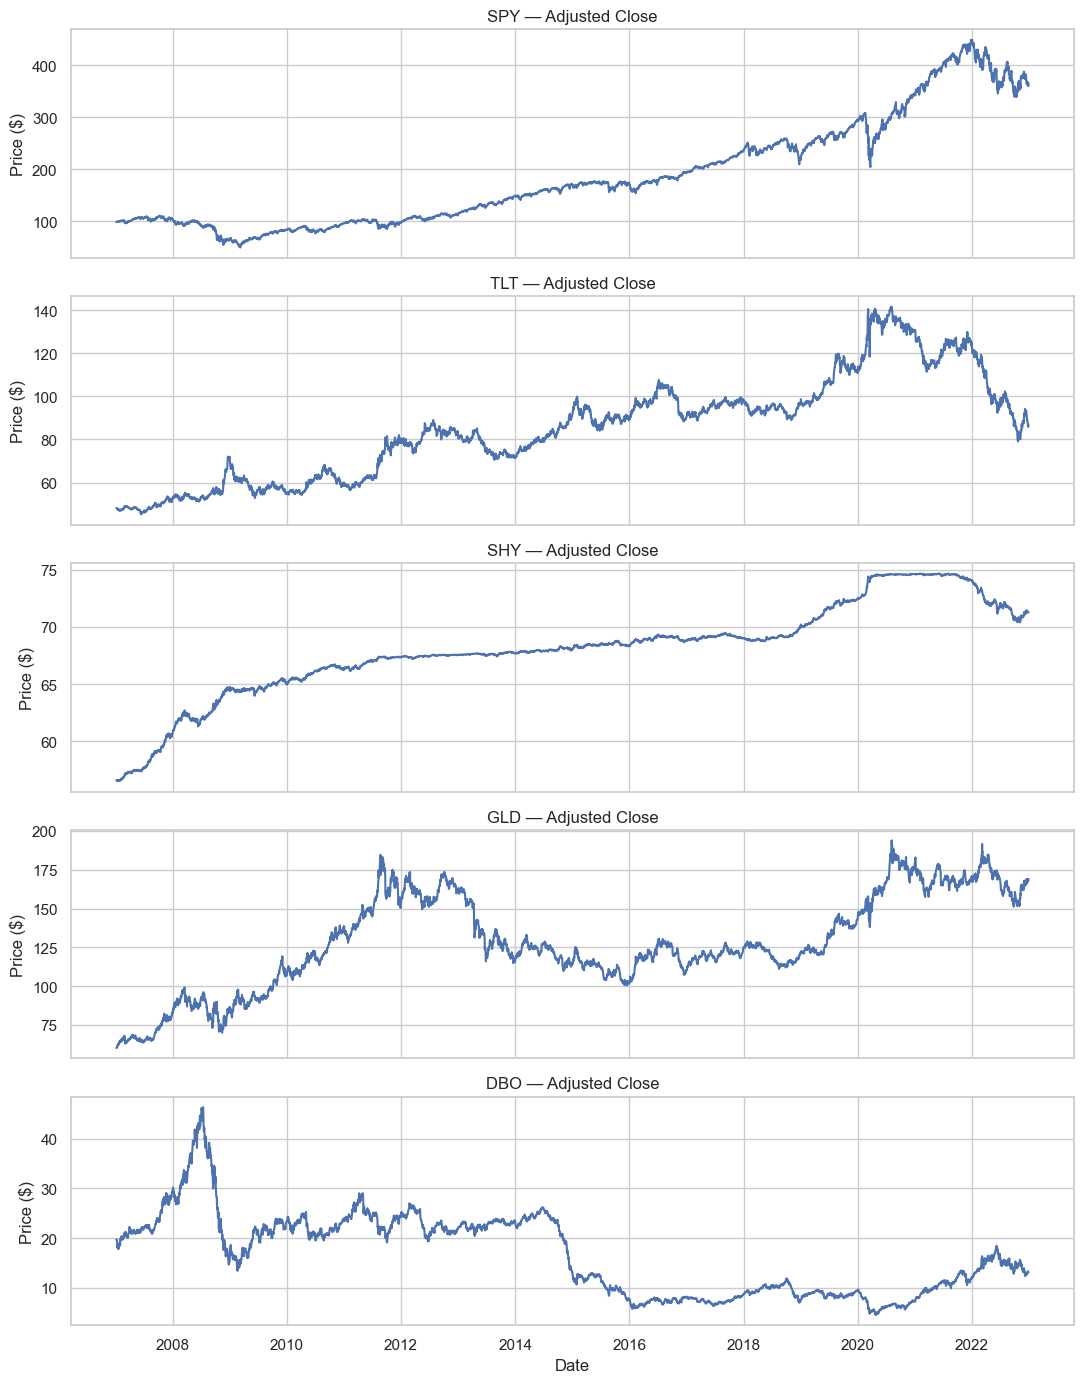

In [6]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(11, 14), sharex=True)
for ax, tkr in zip(axes, TICKERS):
    ax.plot(prices.index, prices[tkr])
    ax.set_title(f"{tkr} — Adjusted Close")
    ax.set_ylabel("Price ($)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### 1.5 Summary statistics on returns

In [7]:
summary_stats = pd.DataFrame({
    "Mean (daily)": returns.mean(),
    "Std Dev (daily)": returns.std(),
    "Annualized Return": returns.mean() * 252,
    "Annualized Vol": returns.std() * np.sqrt(252),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurtosis(),  # excess kurtosis (0 = normal)
    "Min": returns.min(),
    "Max": returns.max(),
})
summary_stats.round(4)

,Mean (daily),Std Dev (daily),Annualized Return,Annualized Vol,Skewness,Kurtosis,Min,Max
Ticker,,,,,,,,
DBO,0.0001,0.0201,0.0258,0.3192,-0.3819,3.9946,-0.1665,0.1062
GLD,0.0003,0.0112,0.0803,0.1770,-0.1090,6.7816,-0.0878,0.1129
SHY,0.0001,0.0009,0.0145,0.0140,0.0118,7.6865,-0.0066,0.0071
SPY,0.0004,0.0129,0.1035,0.2049,-0.0646,13.6391,-0.1094,0.1452
TLT,0.0002,0.0096,0.0485,0.1521,0.0991,3.7135,-0.0667,0.0752


### 1.6 Return distributions (histogram + KDE)

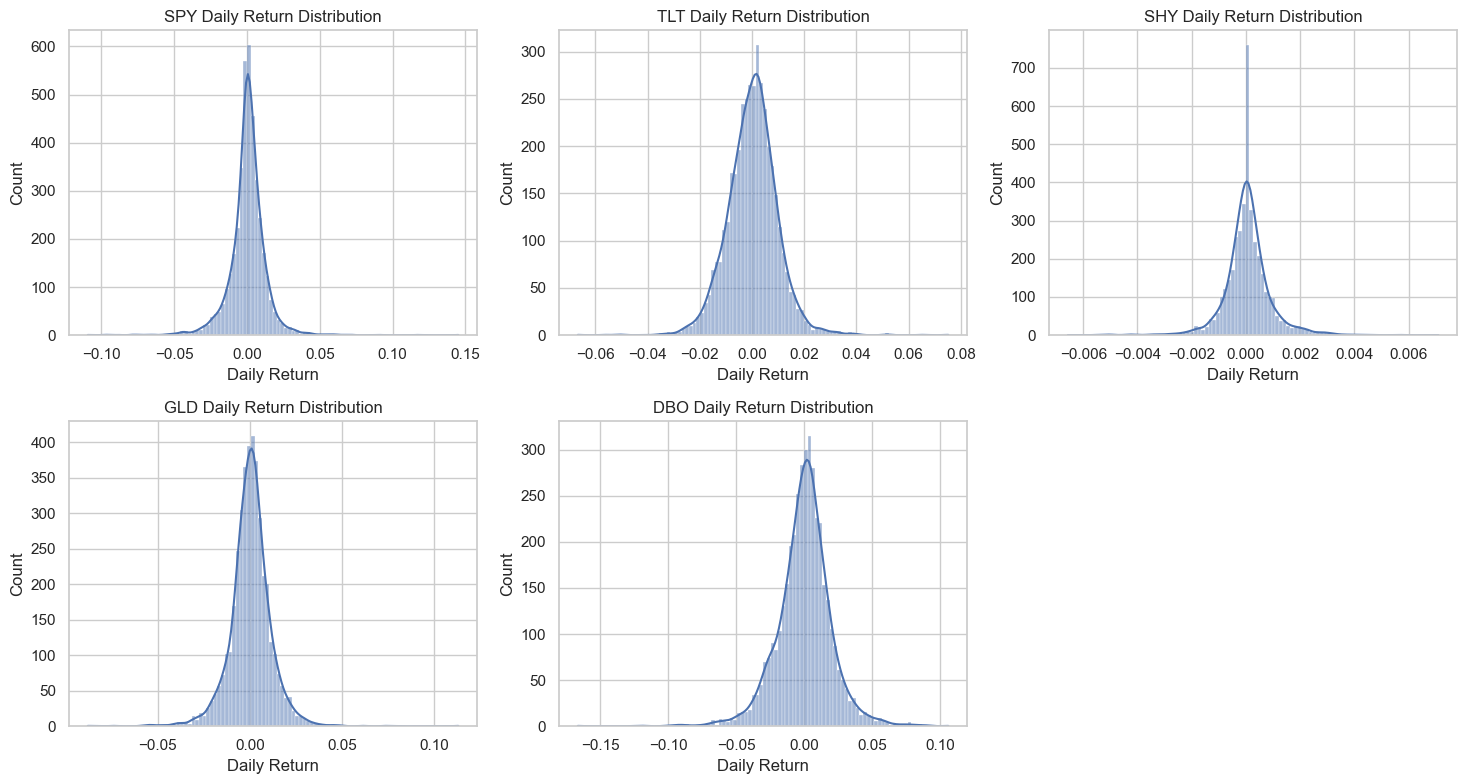

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, tkr in enumerate(TICKERS):
    sns.histplot(returns[tkr], kde=True, ax=axes[i], bins=100)
    axes[i].set_title(f"{tkr} Daily Return Distribution")
    axes[i].set_xlabel("Daily Return")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 1.7 Stationarity: ADF test - prices vs. returns

Most price series are expected to fail to reject the unit-root null, while return series are expected to reject it. The ADF results below determine the final stationarity conclusion.

In [9]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    return {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Stationary (5%)": result[1] < 0.05,
    }

adf_results = []
for tkr in TICKERS:
    adf_results.append(adf_report(prices[tkr], f"{tkr} (price)"))
    adf_results.append(adf_report(returns[tkr], f"{tkr} (return)"))

adf_df = pd.DataFrame(adf_results)
adf_df.round(4)

,Series,ADF Statistic,p-value,Stationary (5%)
0,SPY (price),0.2791,0.9764,False
1,SPY (return),-15.7613,0.0000,True
2,TLT (price),-1.7047,0.4287,False
3,TLT (return),-12.1296,0.0000,True
4,SHY (price),-4.1570,0.0008,True
5,SHY (return),-9.6312,0.0000,True
6,GLD (price),-2.0228,0.2766,False
7,GLD (return),-63.8404,0.0000,True
8,DBO (price),-1.8523,0.3548,False
9,DBO (return),-66.6137,0.0000,True


### 1.8 Seasonality: average return by month / day-of-week

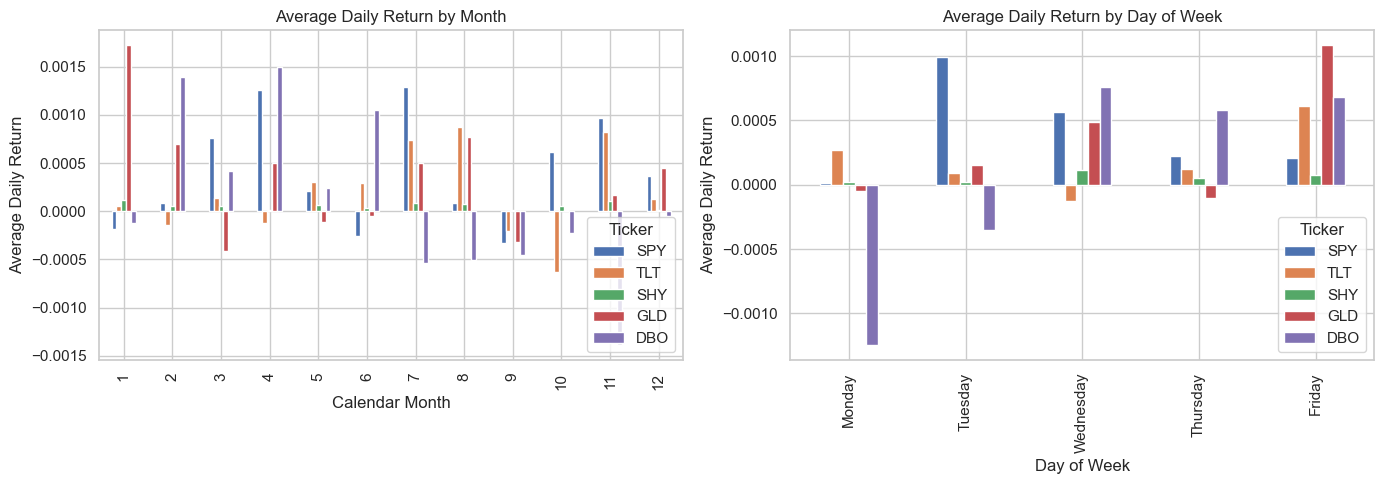

In [10]:
returns_seasonal = returns.copy()
returns_seasonal["month"] = returns_seasonal.index.month
returns_seasonal["dow"] = returns_seasonal.index.day_name()

month_avg = returns_seasonal.groupby("month")[TICKERS].mean()
dow_avg = returns_seasonal.groupby("dow")[TICKERS].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_avg.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Daily Return by Month")
axes[0].set_ylabel("Average Daily Return")
axes[0].set_xlabel("Calendar Month")

dow_avg.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Daily Return by Day of Week")
axes[1].set_ylabel("Average Daily Return")
axes[1].set_xlabel("Day of Week")
plt.tight_layout()
plt.show()


### 1.9 Joint distributions: correlation & covariance

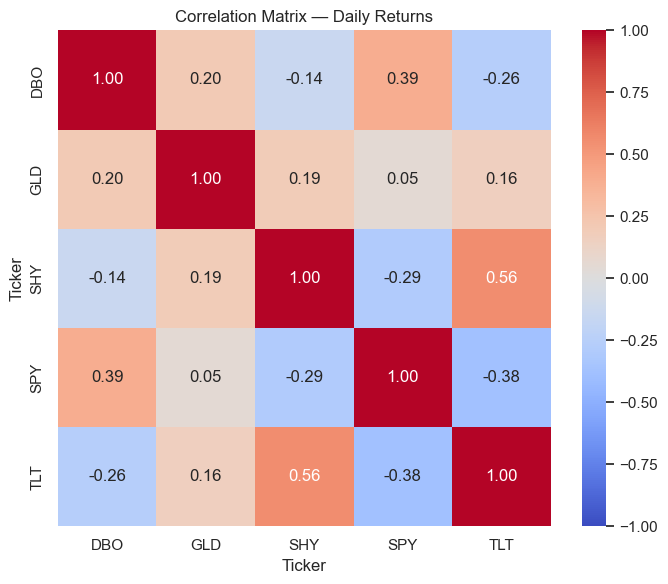

Covariance matrix (daily returns):


Ticker,DBO,GLD,SHY,SPY,TLT
Ticker,,,,,
DBO,0.000404,0.000046,-0.000003,0.000102,-0.000051
GLD,0.000046,0.000124,0.000002,0.000007,0.000017
SHY,-0.000003,0.000002,0.000001,-0.000003,0.000005
SPY,0.000102,0.000007,-0.000003,0.000167,-0.000046
TLT,-0.000051,0.000017,0.000005,-0.000046,0.000092


In [11]:
corr_matrix = returns.corr()
cov_matrix = returns.cov()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix — Daily Returns")
plt.tight_layout()
plt.show()

print("Covariance matrix (daily returns):")
cov_matrix.round(6)

### 1.10 Rolling correlation (SPY vs. each other asset) — regime insight

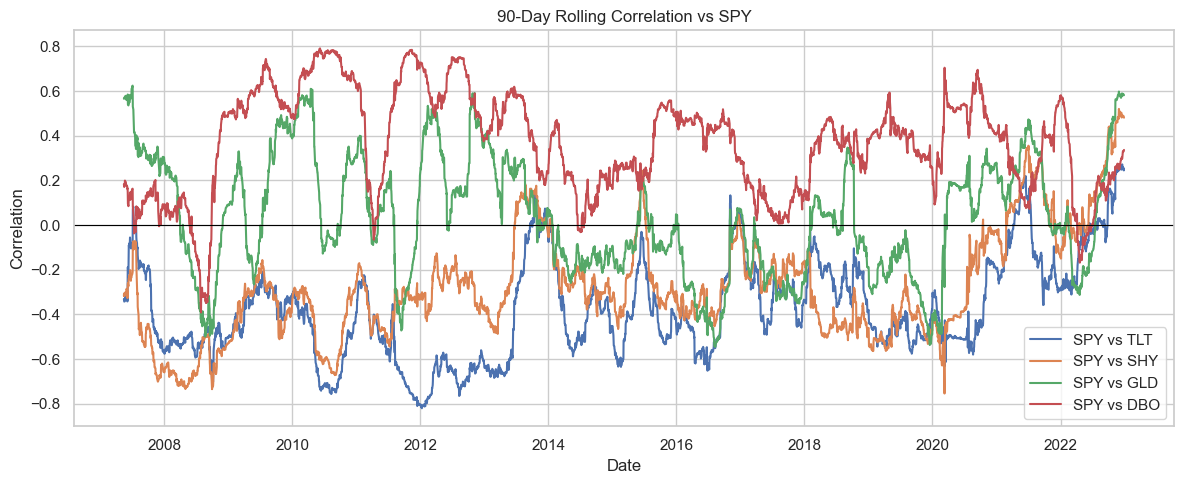

In [12]:
window = 90
plt.figure(figsize=(12, 5))
for tkr in [t for t in TICKERS if t != "SPY"]:
    rolling_corr = returns["SPY"].rolling(window).corr(returns[tkr])
    plt.plot(rolling_corr.index, rolling_corr, label=f"SPY vs {tkr}")
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"{window}-Day Rolling Correlation vs SPY")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()


# **Step 2: Multi-Layer Perceptron (MLP) Baseline**

Each ETF is modelled independently using its own previous 50 daily returns to predict the cumulative return over the following 25 trading days.

The same chronological train, validation, and test boundaries are used throughout Steps 2–5. Samples are assigned to a split only when the complete 25-day target window lies within that period, preventing target leakage across split boundaries.

The MLP is intentionally used as the baseline architecture. It is trained for a fixed 50 epochs with a batch size of 32 and Mean Squared Error (MSE) loss; early stopping is introduced only in the later CNN and LSTM models.


In [13]:
SEED = 642

tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

In [14]:
PAST_DAYS = 50
FUTURE_DAYS = 25

def build_single_asset_samples(return_series, past_days=PAST_DAYS, future_days=FUTURE_DAYS):
    values = return_series.values.astype("float32")
    dates = return_series.index

    X, y, target_start, target_end = [], [], [], []

    for i in range(len(values) - past_days - future_days + 1):
        X.append(values[i:i + past_days])

        future_slice = values[i + past_days:i + past_days + future_days]
        y.append(np.prod(1.0 + future_slice) - 1.0)

        target_start.append(dates[i + past_days])
        target_end.append(dates[i + past_days + future_days - 1])

    return (
        np.asarray(X, dtype="float32"),
        np.asarray(y, dtype="float32"),
        pd.DatetimeIndex(target_start),
        pd.DatetimeIndex(target_end),
    )

TRAIN_END = train.index.max()
VAL_START = val.index.min()
VAL_END = val.index.max()
TEST_START = test.index.min()

def chronological_masks(target_start, target_end):
    train_mask = target_end <= TRAIN_END
    val_mask = (target_start >= VAL_START) & (target_end <= VAL_END)
    test_mask = target_start >= TEST_START
    return train_mask, val_mask, test_mask

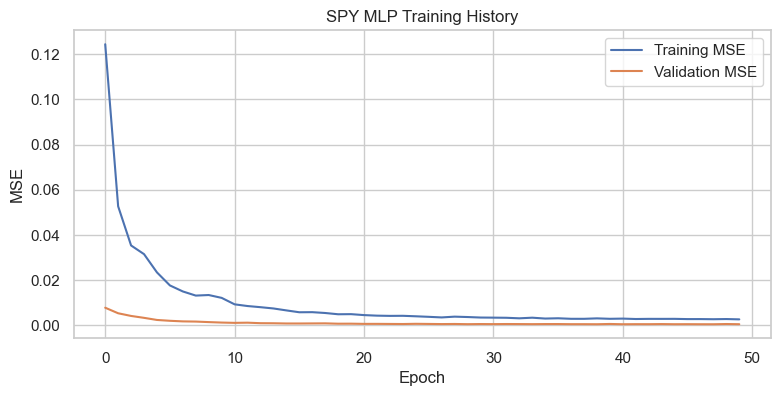

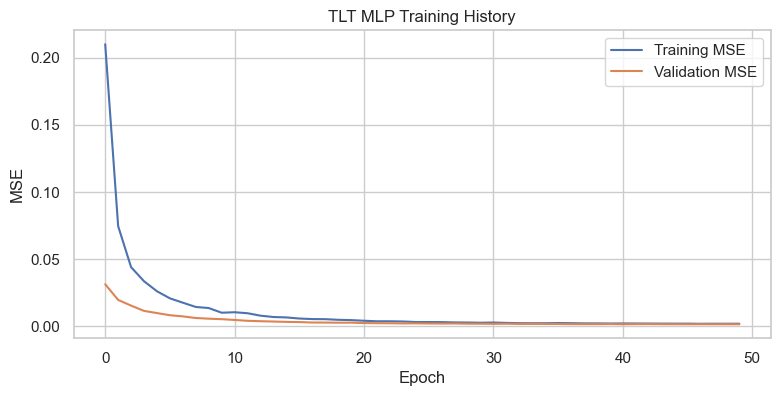

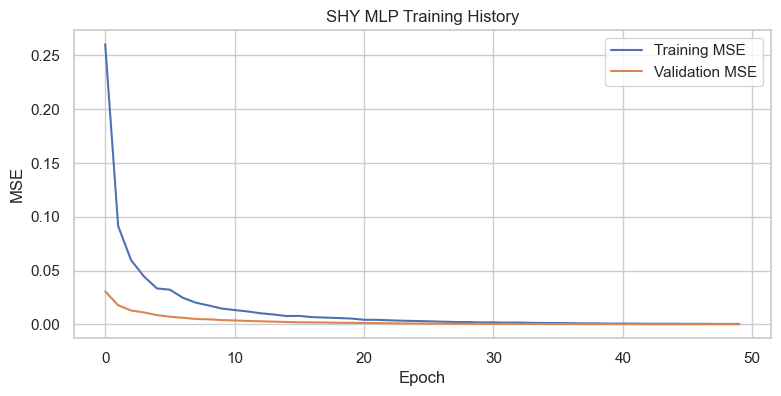

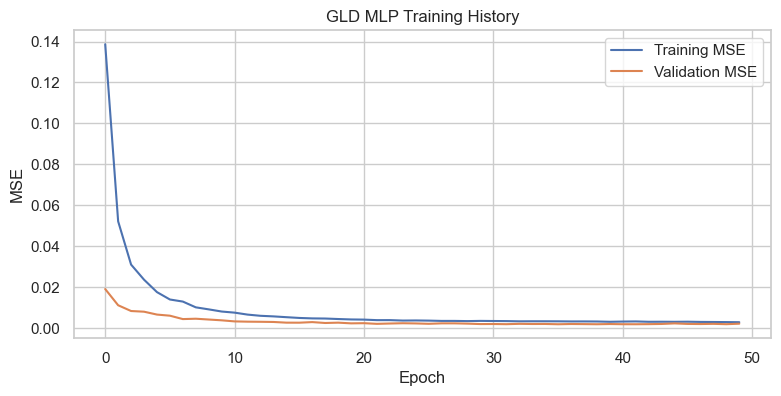

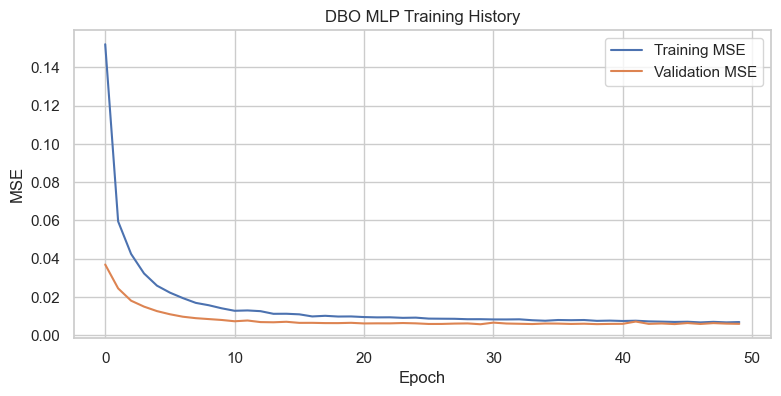

,train_mse,val_mse,test_mse
SPY,0.002281,0.000473,0.003978
TLT,0.001447,0.001509,0.002624
SHY,0.000126,0.000089,0.000238
GLD,0.002752,0.002136,0.002087
DBO,0.004856,0.005948,0.012941


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

mlp_models = {}
mlp_scalers = {}
mlp_results = {}
mlp_predictions = {}

for ticker in TICKERS:
    X, y, target_start, target_end = build_single_asset_samples(returns[ticker])
    train_mask, val_mask, test_mask = chronological_masks(target_start, target_end)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    model = Sequential([
        tf.keras.Input(shape=(PAST_DAYS,)),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    train_mse = model.evaluate(X_train_s, y_train, verbose=0)
    val_mse = model.evaluate(X_val_s, y_val, verbose=0)
    test_mse = model.evaluate(X_test_s, y_test, verbose=0)

    pred = model.predict(X_test_s, verbose=0).reshape(-1)

    mlp_models[ticker] = model
    mlp_scalers[ticker] = scaler
    mlp_predictions[ticker] = {
        "dates": target_start[test_mask],
        "actual": y_test,
        "predicted": pred
    }
    mlp_results[ticker] = {
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse
    }

    plt.figure(figsize=(9, 4))
    plt.plot(history.history["loss"], label="Training MSE")
    plt.plot(history.history["val_loss"], label="Validation MSE")
    plt.title(f"{ticker} MLP Training History")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

mlp_results_df = pd.DataFrame(mlp_results).T
display(mlp_results_df)


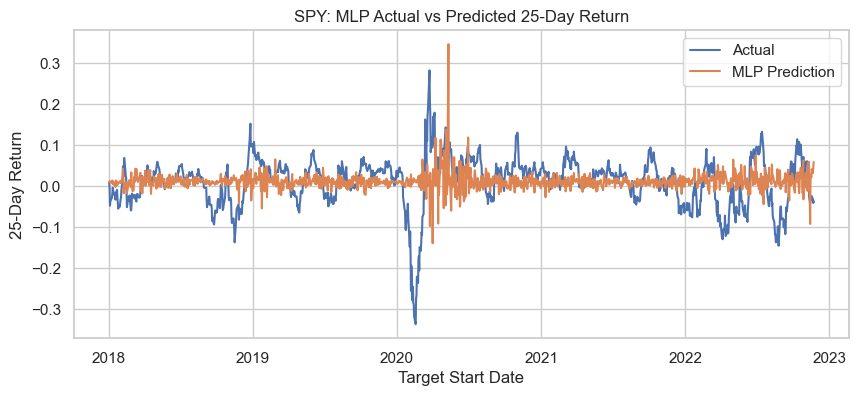

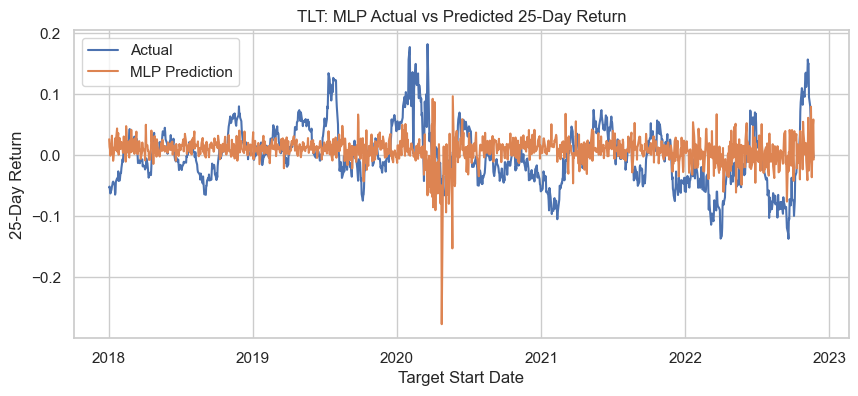

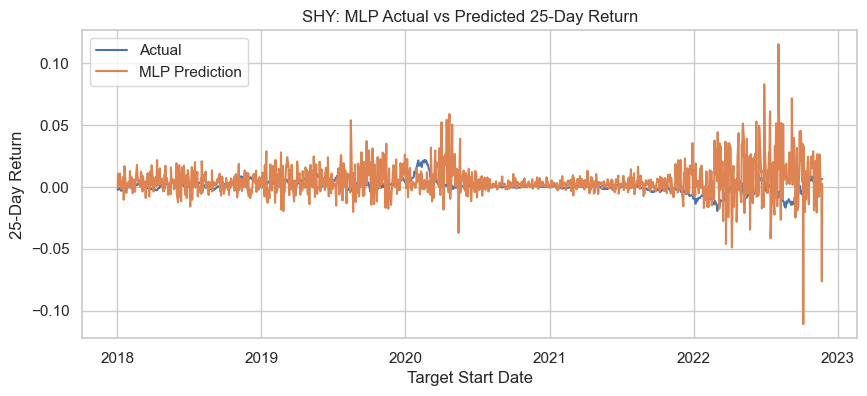

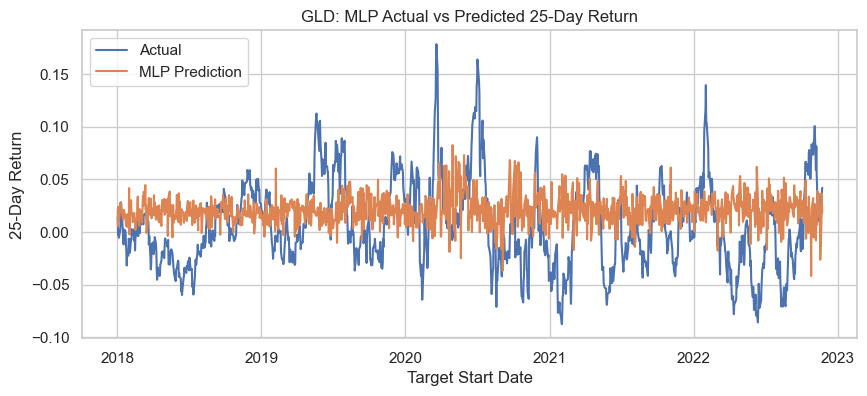

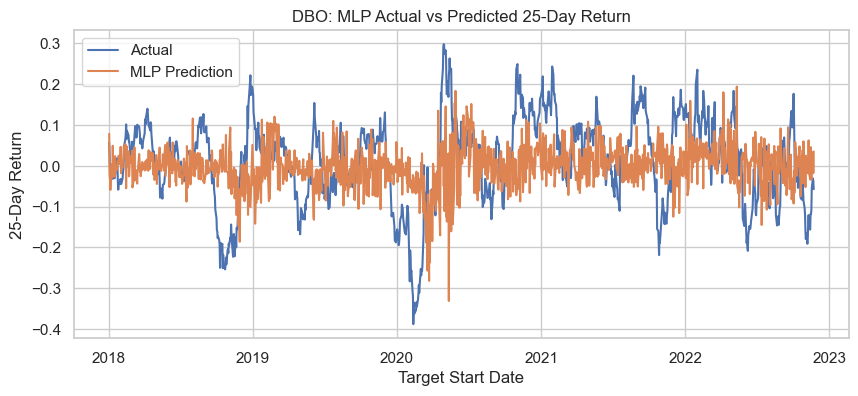

In [16]:
# Step 2: explicit out-of-sample evaluation plots
for ticker in TICKERS:
    item = mlp_predictions[ticker]

    plt.figure(figsize=(10, 4))
    plt.plot(item["dates"], item["actual"], label="Actual")
    plt.plot(item["dates"], item["predicted"], label="MLP Prediction")
    plt.title(f"{ticker}: MLP Actual vs Predicted 25-Day Return")
    plt.xlabel("Target Start Date")
    plt.ylabel("25-Day Return")
    plt.legend()
    plt.show()

# **Step 3: CNN Using Gramian Angular Fields (GAF)**

The forecasting problem is unchanged from Step 2: each ETF still uses the same 50-day return history to predict its own 25-day-ahead cumulative return.

The difference is the representation. Each 50-day sequence is transformed into a 50 × 50 Gramian Angular Field image, and a separate CNN is trained for each ETF. This lets us test whether an image-based representation of relationships within the same return window improves out-of-sample prediction relative to the MLP baseline.


In [17]:
from pyts.image import GramianAngularField
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

gaf = GramianAngularField(
    image_size=PAST_DAYS,
    method="summation",
    sample_range=(-1, 1)
)

def make_gaf_images(X):
    # pyts transforms each 1-D sample into a 2-D PAST_DAYS x PAST_DAYS image
    images = gaf.fit_transform(X)
    return images[..., np.newaxis].astype("float32")

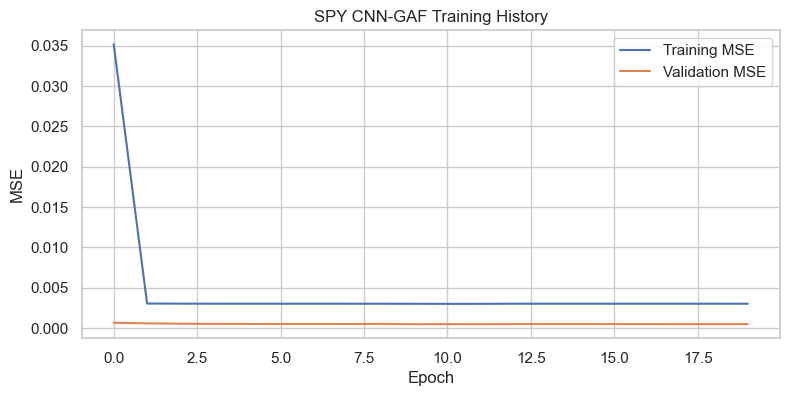

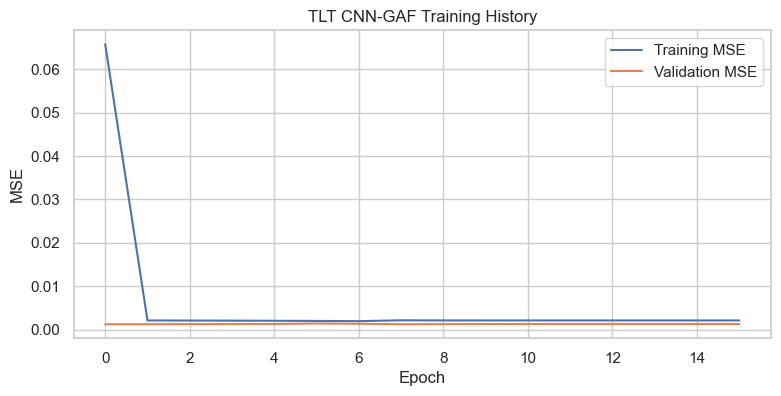

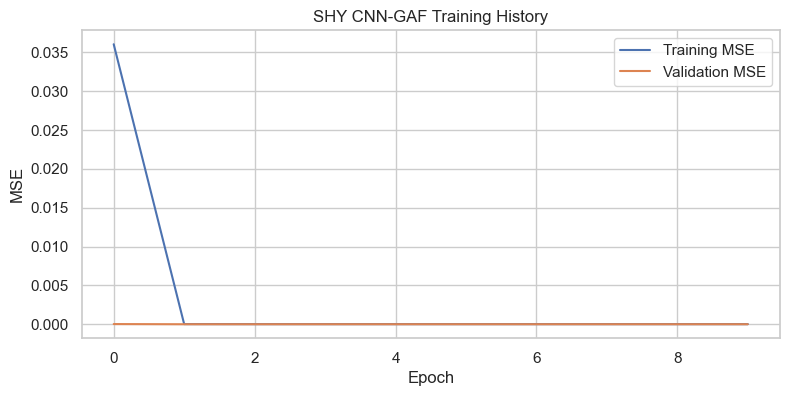

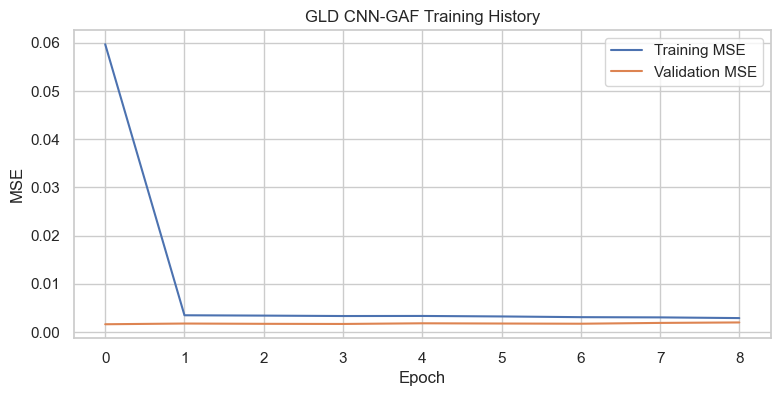

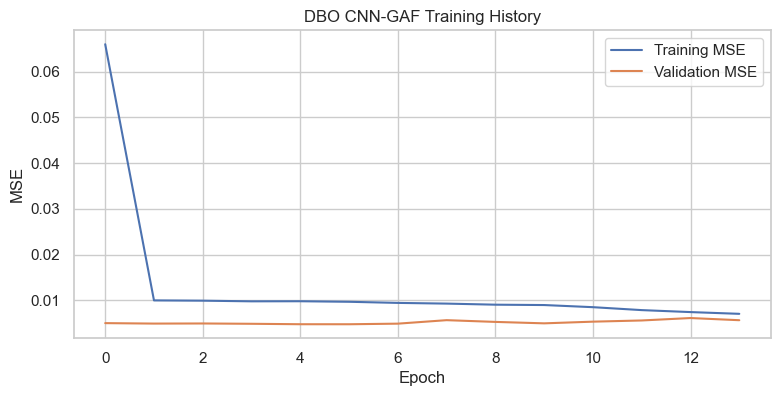

,train_mse,val_mse,test_mse
SPY,0.003010,0.000463,0.003540
TLT,0.002133,0.001251,0.002298
SHY,0.000021,0.000006,0.000027
GLD,0.003444,0.001595,0.001702
DBO,0.009438,0.004729,0.011741


In [18]:
cnn_models = {}
cnn_results = {}
cnn_predictions = {}
gaf_examples = {}

for ticker in TICKERS:
    X, y, target_start, target_end = build_single_asset_samples(returns[ticker])
    train_mask, val_mask, test_mask = chronological_masks(target_start, target_end)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    X_train_gaf = make_gaf_images(X_train)
    X_val_gaf = make_gaf_images(X_val)
    X_test_gaf = make_gaf_images(X_test)

    # Save one example per ETF for the report
    gaf_examples[ticker] = X_train_gaf[0, :, :, 0]

    model = Sequential([
        tf.keras.Input(shape=(PAST_DAYS, PAST_DAYS, 1)),
        Conv2D(16, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_gaf, y_train,
        validation_data=(X_val_gaf, y_val),
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[es]
    )

    train_mse = model.evaluate(X_train_gaf, y_train, verbose=0)
    val_mse = model.evaluate(X_val_gaf, y_val, verbose=0)
    test_mse = model.evaluate(X_test_gaf, y_test, verbose=0)
    pred = model.predict(X_test_gaf, verbose=0).reshape(-1)

    cnn_models[ticker] = model
    cnn_predictions[ticker] = {
        "dates": target_start[test_mask],
        "actual": y_test,
        "predicted": pred
    }
    cnn_results[ticker] = {
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse
    }

    plt.figure(figsize=(9, 4))
    plt.plot(history.history["loss"], label="Training MSE")
    plt.plot(history.history["val_loss"], label="Validation MSE")
    plt.title(f"{ticker} CNN-GAF Training History")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

cnn_results_df = pd.DataFrame(cnn_results).T
display(cnn_results_df)


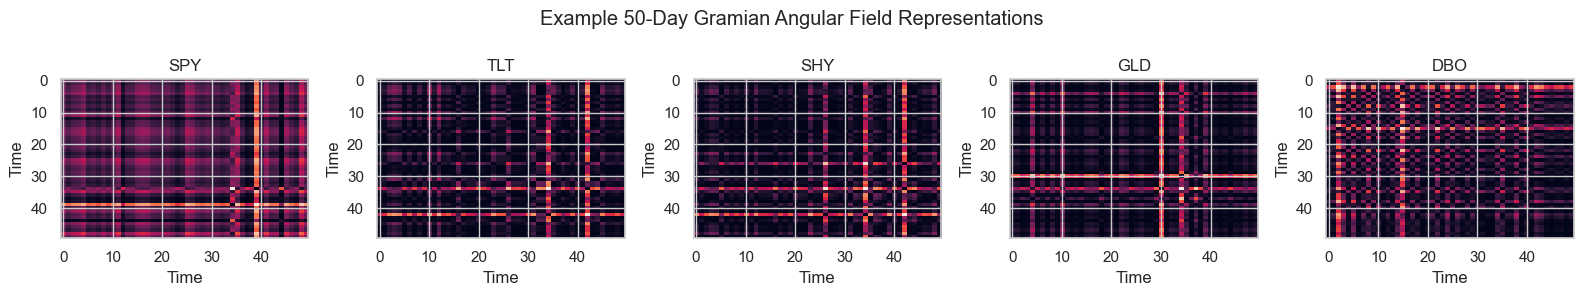

In [19]:
# GAF representations for the five ETFs
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 3))
for ax, ticker in zip(axes, TICKERS):
    im = ax.imshow(gaf_examples[ticker], aspect="auto")
    ax.set_title(ticker)
    ax.set_xlabel("Time")
    ax.set_ylabel("Time")
fig.suptitle("Example 50-Day Gramian Angular Field Representations")
plt.tight_layout()
plt.show()


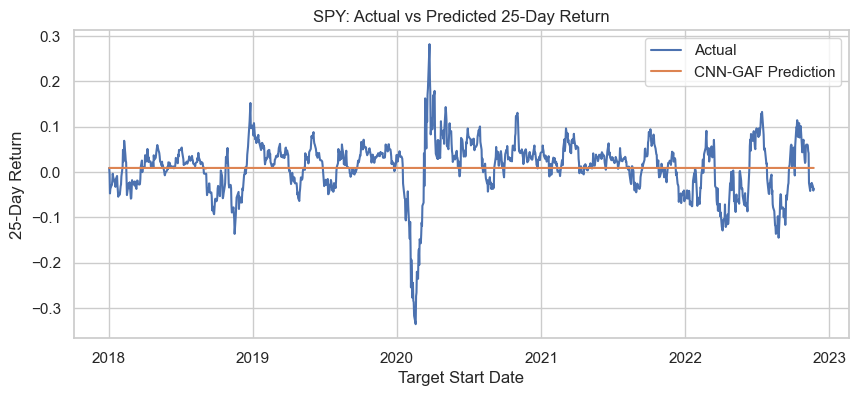

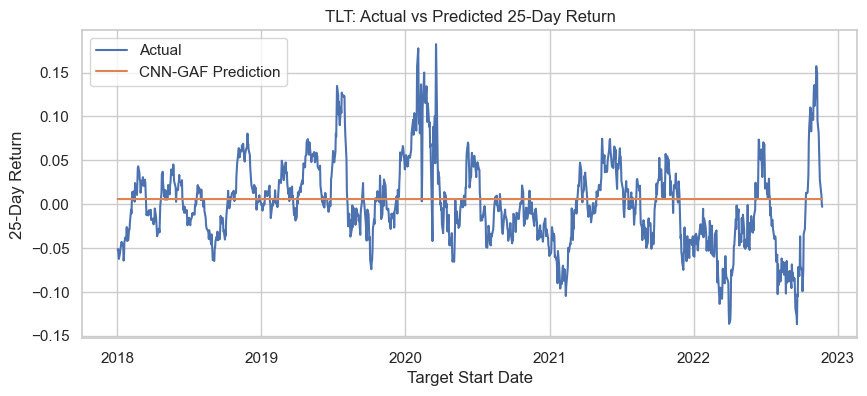

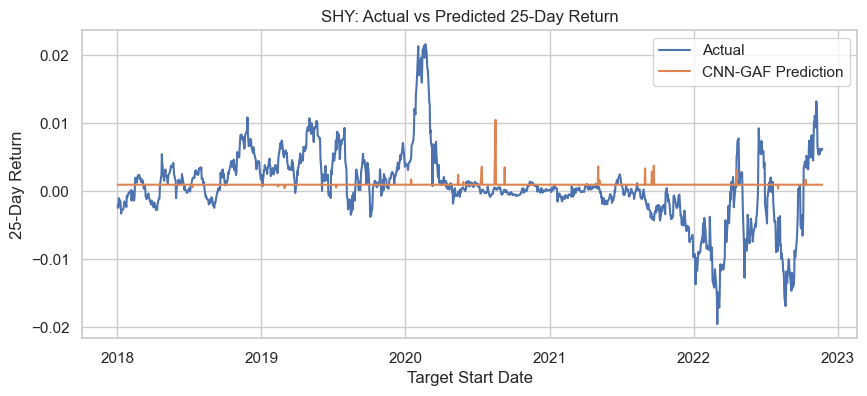

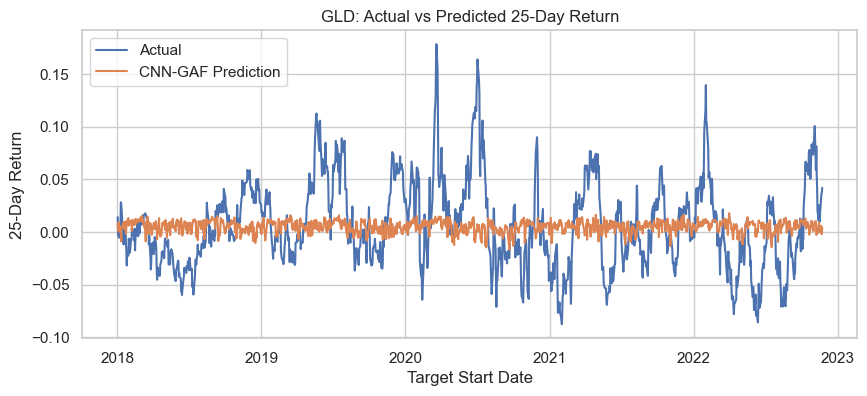

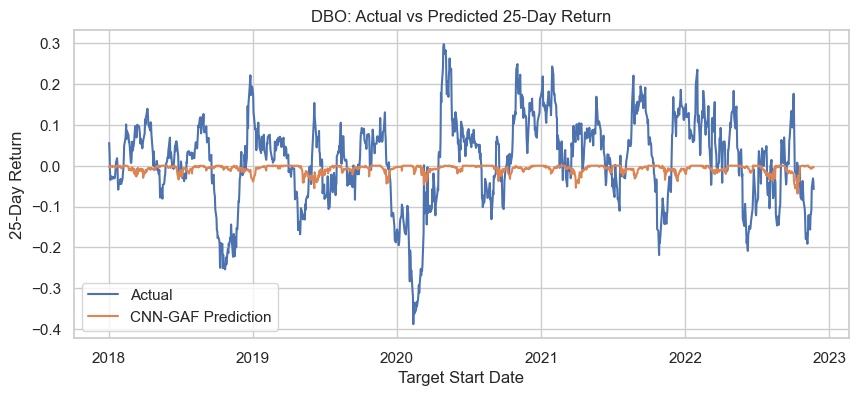

,MLP Test MSE,CNN-GAF Test MSE,Better Test Model
SPY,0.003978,0.003540,CNN-GAF
TLT,0.002624,0.002298,CNN-GAF
SHY,0.000238,0.000027,CNN-GAF
GLD,0.002087,0.001702,CNN-GAF
DBO,0.012941,0.011741,CNN-GAF


In [20]:
# Step 3: Out-of-sample actual vs predicted
for ticker in TICKERS:
    item = cnn_predictions[ticker]
    plt.figure(figsize=(10, 4))
    plt.plot(item["dates"], item["actual"], label="Actual")
    plt.plot(item["dates"], item["predicted"], label="CNN-GAF Prediction")
    plt.title(f"{ticker}: Actual vs Predicted 25-Day Return")
    plt.xlabel("Target Start Date")
    plt.ylabel("25-Day Return")
    plt.legend()
    plt.show()

# Direct MLP vs CNN-GAF comparison
step23_comparison = pd.DataFrame({
    "MLP Test MSE": mlp_results_df["test_mse"],
    "CNN-GAF Test MSE": cnn_results_df["test_mse"]
})
step23_comparison["Better Test Model"] = np.where(
    step23_comparison["MLP Test MSE"] <= step23_comparison["CNN-GAF Test MSE"],
    "MLP",
    "CNN-GAF"
)
display(step23_comparison)


# **Step 4: Single-Output LSTM Models**

Step 4 keeps the same 50-day input window, 25-day-ahead cumulative-return target, chronological splits, and MSE evaluation used in Steps 2 and 3.

For each ETF:

**50 historical daily returns -> stacked LSTM -> one 25-day-ahead return**

The return values are standardized using training data only. Each model uses early stopping on validation loss with the best validation weights restored.


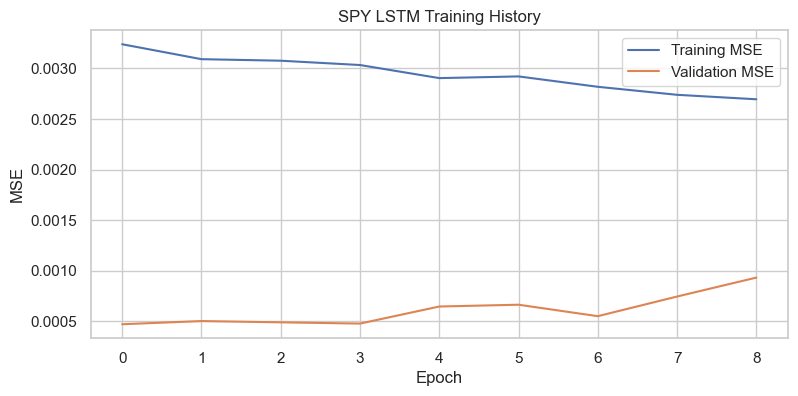

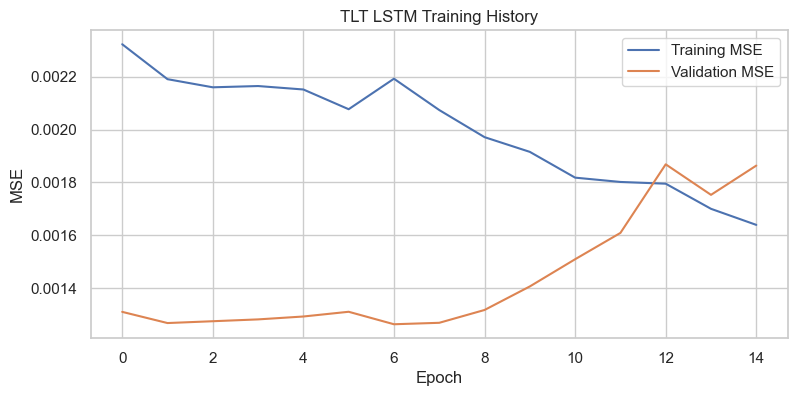

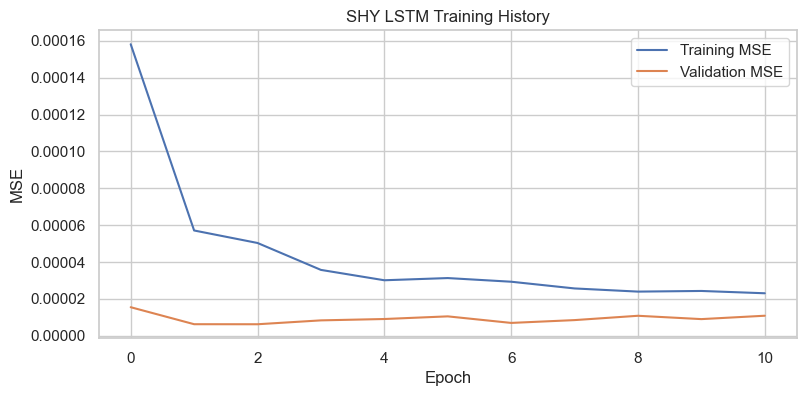

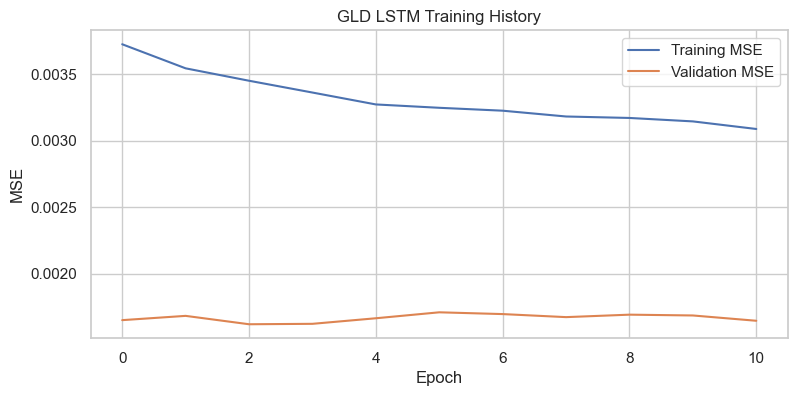

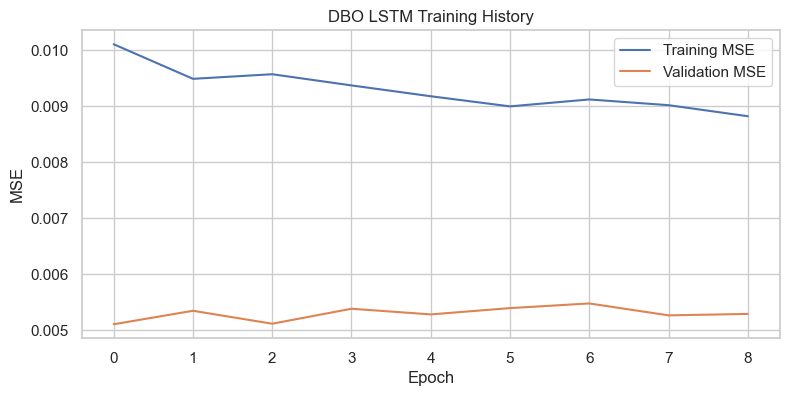

,train_mse,val_mse,test_mse
SPY,0.003002,0.000472,0.004134
TLT,0.002040,0.001263,0.002364
SHY,0.000016,0.000006,0.000028
GLD,0.003255,0.001620,0.001713
DBO,0.009139,0.005108,0.011363


In [21]:
lstm_models = {}
lstm_scalers = {}
lstm_results = {}
lstm_predictions = {}

for ticker in TICKERS:
    X, y, target_start, target_end = build_single_asset_samples(returns[ticker])
    train_mask, val_mask, test_mask = chronological_masks(target_start, target_end)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    # Scale using training returns only. Scaling is fitted over individual return values.
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))

    X_train_s = scaler.transform(X_train.reshape(-1, 1)).reshape(-1, PAST_DAYS, 1)
    X_val_s = scaler.transform(X_val.reshape(-1, 1)).reshape(-1, PAST_DAYS, 1)
    X_test_s = scaler.transform(X_test.reshape(-1, 1)).reshape(-1, PAST_DAYS, 1)

    model = Sequential([
        tf.keras.Input(shape=(PAST_DAYS, 1)),
        LSTM(50, return_sequences=True),
        Dropout(0.20),
        LSTM(25),
        Dropout(0.20),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[es]
    )

    train_mse = model.evaluate(X_train_s, y_train, verbose=0)
    val_mse = model.evaluate(X_val_s, y_val, verbose=0)
    test_mse = model.evaluate(X_test_s, y_test, verbose=0)
    pred = model.predict(X_test_s, verbose=0).reshape(-1)

    lstm_models[ticker] = model
    lstm_scalers[ticker] = scaler
    lstm_predictions[ticker] = {
        "dates": target_start[test_mask],
        "actual": y_test,
        "predicted": pred
    }
    lstm_results[ticker] = {
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse
    }

    plt.figure(figsize=(9, 4))
    plt.plot(history.history["loss"], label="Training MSE")
    plt.plot(history.history["val_loss"], label="Validation MSE")
    plt.title(f"{ticker} LSTM Training History")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

lstm_results_df = pd.DataFrame(lstm_results).T
display(lstm_results_df)


,MLP Test MSE,CNN-GAF Test MSE,LSTM Test MSE,Best Architecture
SPY,0.003978,0.003540,0.004134,CNN-GAF Test MSE
TLT,0.002624,0.002298,0.002364,CNN-GAF Test MSE
SHY,0.000238,0.000027,0.000028,CNN-GAF Test MSE
GLD,0.002087,0.001702,0.001713,CNN-GAF Test MSE
DBO,0.012941,0.011741,0.011363,LSTM Test MSE


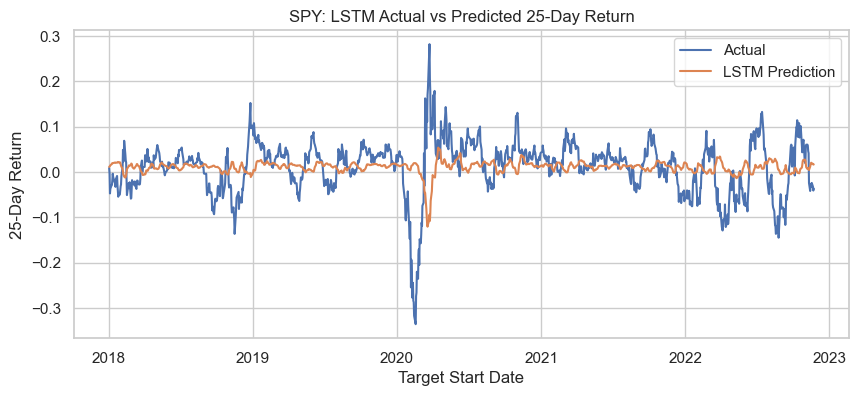

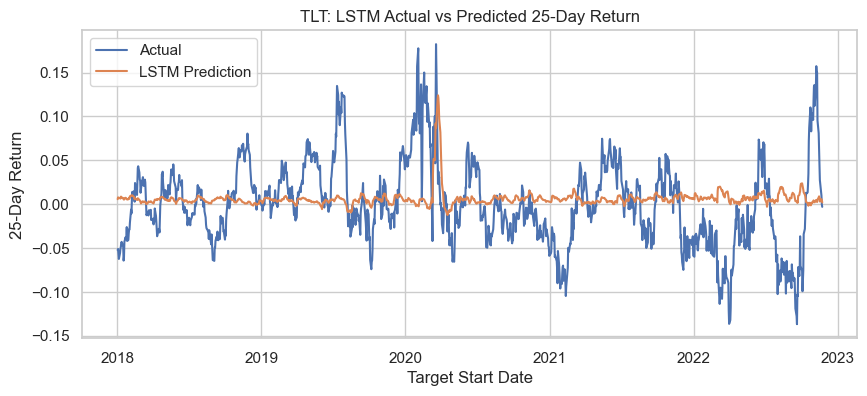

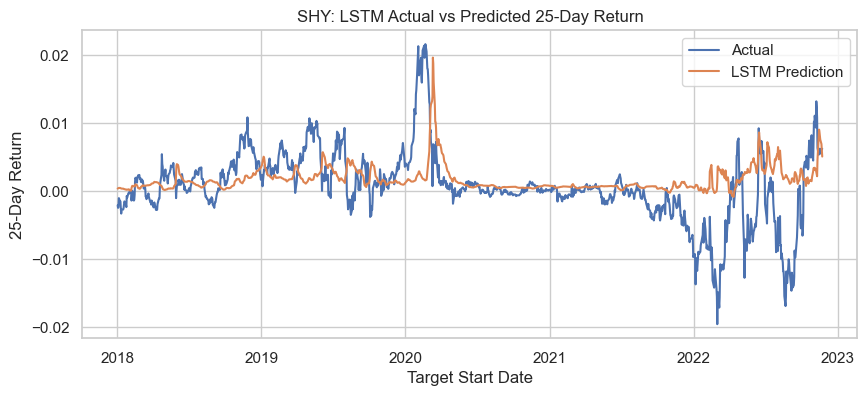

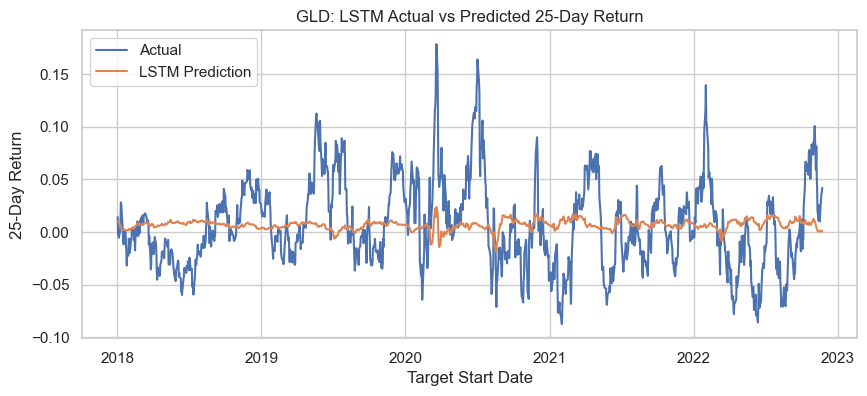

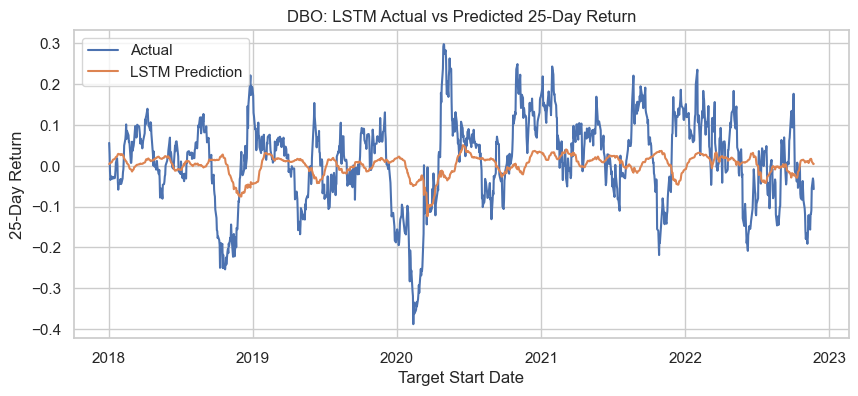

In [22]:
# Step 4 comparison against Steps 2 and 3
architecture_comparison = pd.DataFrame({
    "MLP Test MSE": mlp_results_df["test_mse"],
    "CNN-GAF Test MSE": cnn_results_df["test_mse"],
    "LSTM Test MSE": lstm_results_df["test_mse"]
})

architecture_comparison["Best Architecture"] = architecture_comparison.idxmin(axis=1)
display(architecture_comparison)

for ticker in TICKERS:
    item = lstm_predictions[ticker]
    plt.figure(figsize=(10, 4))
    plt.plot(item["dates"], item["actual"], label="Actual")
    plt.plot(item["dates"], item["predicted"], label="LSTM Prediction")
    plt.title(f"{ticker}: LSTM Actual vs Predicted 25-Day Return")
    plt.xlabel("Target Start Date")
    plt.ylabel("25-Day Return")
    plt.legend()
    plt.show()


# **Step 5: Multi-Output LSTM**

The five Step 4 models make forecasts independently, so each model only sees the historical returns of its own ETF.

Step 5 broadens the information set. Five separate 50-day return sequences are encoded in parallel, their learned representations are combined, and the shared network predicts the five 25-day-ahead ETF returns jointly:

**five ETF return histories → five LSTM encoders → shared representation → five return forecasts**

The joint model is trained from scratch rather than initialized with the Step 4 weights. This isolates the effect of joint learning and cross-asset information from transfer learning.


In [23]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Concatenate

# Build one common set of dates/targets because the five ETF return series are aligned.
all_values = returns[TICKERS].values.astype("float32")
all_dates = returns.index

X_all, y_all, target_start_all, target_end_all = [], [], [], []

for i in range(len(all_values) - PAST_DAYS - FUTURE_DAYS + 1):
    X_all.append(all_values[i:i + PAST_DAYS, :])

    future_slice = all_values[i + PAST_DAYS:i + PAST_DAYS + FUTURE_DAYS, :]
    y_all.append(np.prod(1.0 + future_slice, axis=0) - 1.0)

    target_start_all.append(all_dates[i + PAST_DAYS])
    target_end_all.append(all_dates[i + PAST_DAYS + FUTURE_DAYS - 1])

X_all = np.asarray(X_all, dtype="float32")
y_all = np.asarray(y_all, dtype="float32")
target_start_all = pd.DatetimeIndex(target_start_all)
target_end_all = pd.DatetimeIndex(target_end_all)

train_mask, val_mask, test_mask = chronological_masks(target_start_all, target_end_all)

X_train_all, y_train_all = X_all[train_mask], y_all[train_mask]
X_val_all, y_val_all = X_all[val_mask], y_all[val_mask]
X_test_all, y_test_all = X_all[test_mask], y_all[test_mask]

# Scale each ETF from the training set only.
multi_scalers = {}
for j, ticker in enumerate(TICKERS):
    scaler = StandardScaler()
    scaler.fit(X_train_all[:, :, j].reshape(-1, 1))

    X_train_all[:, :, j] = scaler.transform(
        X_train_all[:, :, j].reshape(-1, 1)
    ).reshape(X_train_all.shape[0], PAST_DAYS)

    X_val_all[:, :, j] = scaler.transform(
        X_val_all[:, :, j].reshape(-1, 1)
    ).reshape(X_val_all.shape[0], PAST_DAYS)

    X_test_all[:, :, j] = scaler.transform(
        X_test_all[:, :, j].reshape(-1, 1)
    ).reshape(X_test_all.shape[0], PAST_DAYS)

    multi_scalers[ticker] = scaler


Multi-output training MSE: 0.0033910642378032207
Multi-output validation MSE: 0.0017455370398238301
Multi-output test MSE: 0.0038136879447847605


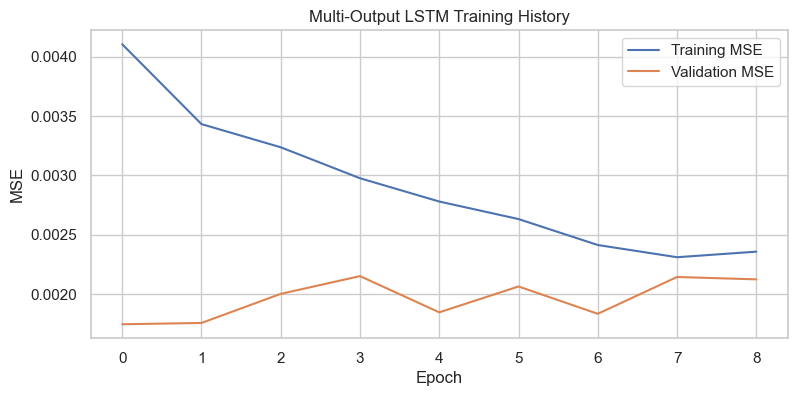

In [24]:
# Five parallel LSTM encoders, followed by a shared five-output prediction head.
inputs = []
encoded = []

for j, ticker in enumerate(TICKERS):
    inp = Input(shape=(PAST_DAYS, 1), name=f"{ticker}_input")
    x = LSTM(50, name=f"{ticker}_lstm")(inp)
    x = Dropout(0.20, name=f"{ticker}_dropout")(x)

    inputs.append(inp)
    encoded.append(x)

merged = Concatenate(name="cross_asset_merge")(encoded)
x = Dense(64, activation="relu", name="shared_dense")(merged)
x = Dropout(0.20, name="shared_dropout")(x)
outputs = Dense(len(TICKERS), name="five_return_outputs")(x)

multi_model = Model(inputs=inputs, outputs=outputs)
multi_model.compile(optimizer="adam", loss="mse")

def split_inputs(X):
    return [X[:, :, j:j+1] for j in range(len(TICKERS))]

es = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = multi_model.fit(
    split_inputs(X_train_all),
    y_train_all,
    validation_data=(split_inputs(X_val_all), y_val_all),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[es]
)

multi_train_mse = multi_model.evaluate(
    split_inputs(X_train_all), y_train_all, verbose=0
)
multi_val_mse = multi_model.evaluate(
    split_inputs(X_val_all), y_val_all, verbose=0
)
multi_test_mse = multi_model.evaluate(
    split_inputs(X_test_all), y_test_all, verbose=0
)

print("Multi-output training MSE:", multi_train_mse)
print("Multi-output validation MSE:", multi_val_mse)
print("Multi-output test MSE:", multi_test_mse)

plt.figure(figsize=(9, 4))
plt.plot(history.history["loss"], label="Training MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.title("Multi-Output LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


,train_mse,val_mse,test_mse
SPY,0.002563,0.000513,0.003625
TLT,0.001973,0.001381,0.002378
SHY,0.000066,0.000025,0.000070
GLD,0.003325,0.001612,0.001647
DBO,0.009028,0.005197,0.011348


,Single LSTM Train MSE,Multi-Output Train MSE,Single LSTM Val MSE,Multi-Output Val MSE,Single LSTM Test MSE,Multi-Output Test MSE,Multi-Output Test Improvement (%)
SPY,0.003002,0.002563,0.000472,0.000513,0.004134,0.003625,12.304683
TLT,0.002040,0.001973,0.001263,0.001381,0.002364,0.002378,-0.582877
SHY,0.000016,0.000066,0.000006,0.000025,0.000028,0.000070,-150.159575
GLD,0.003255,0.003325,0.001620,0.001612,0.001713,0.001647,3.861067
DBO,0.009139,0.009028,0.005108,0.005197,0.011363,0.011348,0.128995


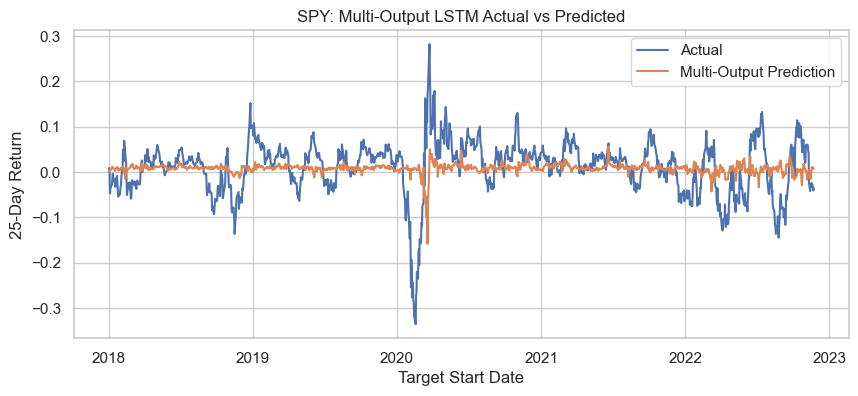

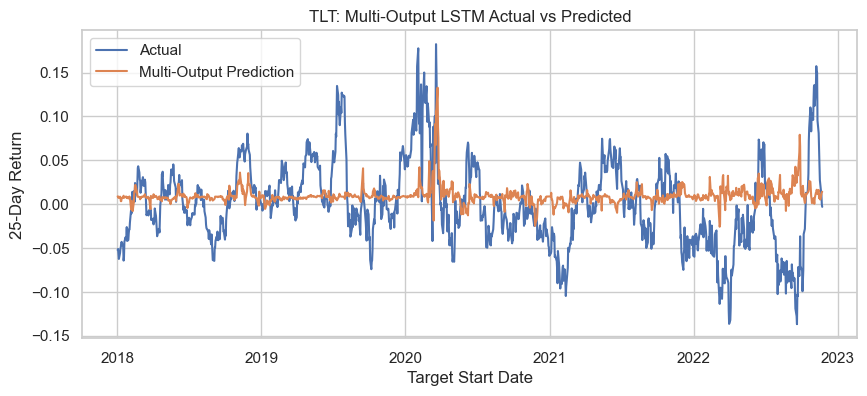

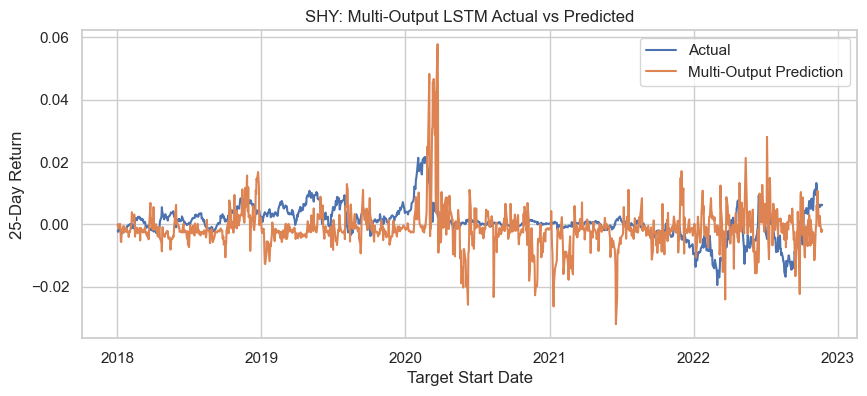

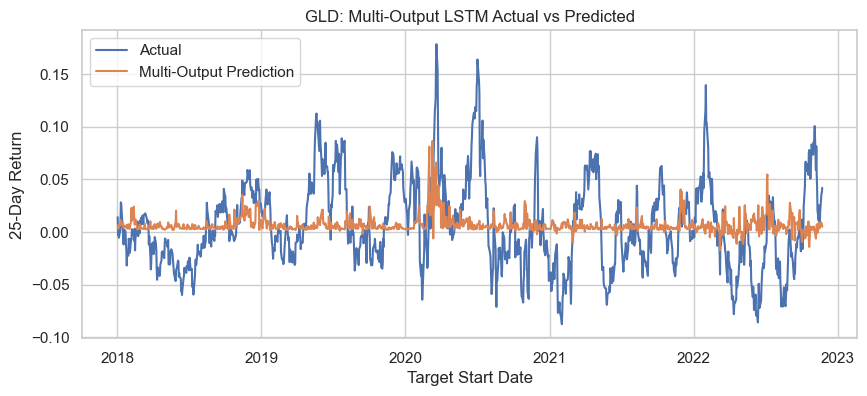

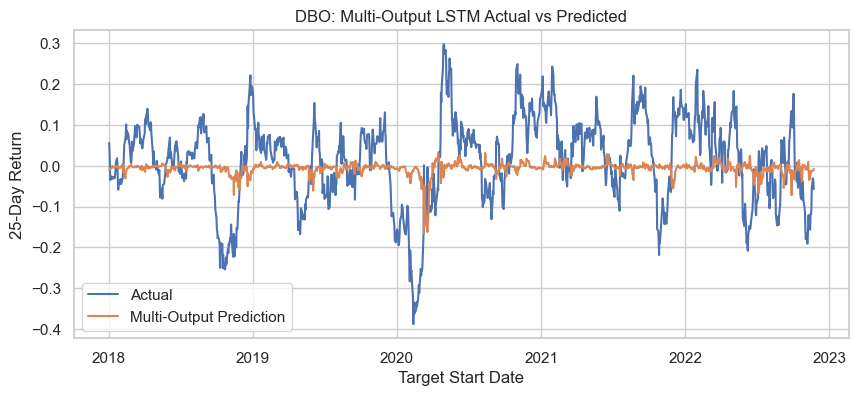

In [25]:
# Step 5: Per-ETF in-sample, validation, and out-of-sample performance
multi_pred_train = multi_model.predict(split_inputs(X_train_all), verbose=0)
multi_pred_val = multi_model.predict(split_inputs(X_val_all), verbose=0)
multi_pred_test = multi_model.predict(split_inputs(X_test_all), verbose=0)

multi_per_asset_results = {}

for j, ticker in enumerate(TICKERS):
    multi_per_asset_results[ticker] = {
        "train_mse": mean_squared_error(y_train_all[:, j], multi_pred_train[:, j]),
        "val_mse": mean_squared_error(y_val_all[:, j], multi_pred_val[:, j]),
        "test_mse": mean_squared_error(y_test_all[:, j], multi_pred_test[:, j]),
    }

multi_results_df = pd.DataFrame(multi_per_asset_results).T
display(multi_results_df)

# Direct Step 4 vs Step 5 comparison for each ETF
step45_comparison = pd.DataFrame({
    "Single LSTM Train MSE": lstm_results_df["train_mse"],
    "Multi-Output Train MSE": multi_results_df["train_mse"],
    "Single LSTM Val MSE": lstm_results_df["val_mse"],
    "Multi-Output Val MSE": multi_results_df["val_mse"],
    "Single LSTM Test MSE": lstm_results_df["test_mse"],
    "Multi-Output Test MSE": multi_results_df["test_mse"],
})

step45_comparison["Multi-Output Test Improvement (%)"] = (
    (step45_comparison["Single LSTM Test MSE"]
     - step45_comparison["Multi-Output Test MSE"])
    / step45_comparison["Single LSTM Test MSE"]
    * 100
)

display(step45_comparison)

# Step 5: out-of-sample actual vs predicted plots
for j, ticker in enumerate(TICKERS):
    plt.figure(figsize=(10, 4))
    plt.plot(target_start_all[test_mask], y_test_all[:, j], label="Actual")
    plt.plot(target_start_all[test_mask], multi_pred_test[:, j], label="Multi-Output Prediction")
    plt.title(f"{ticker}: Multi-Output LSTM Actual vs Predicted")
    plt.xlabel("Target Start Date")
    plt.ylabel("25-Day Return")
    plt.legend()
    plt.show()


# **Step 6: Asset Allocation Strategy and Backtest**

Step 6 translates the **out-of-sample predictions from the Step 5 multi-output model** into an asset-allocation strategy.

At every 25-trading-day rebalance:

- rank the five ETFs by predicted 25-day-ahead return;
- go long the two highest-ranked ETFs;
- go short the two lowest-ranked ETFs;
- leave the middle-ranked ETF unallocated;
- allocate +25% to each long position and −25% to each short position.

The strategy therefore uses predictions from four of the five asset classes at every rebalance, has 100% gross exposure and 0% net exposure, and matches the 25-day forecast horizon as required.


In [26]:
# Build the Step 6 inputs directly from the Step 5 outputs.

prediction_dates = target_start_all[test_mask]
target_end_dates = target_end_all[test_mask]

predictions = pd.DataFrame(
    multi_pred_test,
    index=prediction_dates,
    columns=TICKERS
)

actual_25d_returns = pd.DataFrame(
    y_test_all,
    index=prediction_dates,
    columns=TICKERS
)

target_end_by_start = pd.Series(
    target_end_dates,
    index=prediction_dates,
    name="target_end"
)

print("Step 5 prediction matrix:", predictions.shape)
print(
    "Available forecast start dates:",
    predictions.index.min().date(),
    "to",
    predictions.index.max().date()
)
display(predictions.head())


Step 5 prediction matrix: (1234, 5)
Available forecast start dates: 2018-01-02 to 2022-11-23


,SPY,TLT,SHY,GLD,DBO
2018-01-02,0.000779,0.008763,-0.000442,0.002660,-0.010161
2018-01-03,0.002302,0.008786,0.000071,0.004017,-0.008748
2018-01-04,0.004284,0.007071,-0.001223,0.006760,-0.007840
2018-01-05,0.003595,0.007204,-0.001275,0.006222,-0.008308
2018-01-08,0.007757,0.008507,0.000100,0.006081,-0.004389


### 6.1 Rebalancing schedule and portfolio weights

Because each forecast covers the next 25 trading days, we only act on every 25th forecast. This avoids overlapping holding periods.

The prediction associated with a rebalance date is based only on the 50 returns before that target period begins, so the position can be formed for that forecast window without using future information.

In [27]:
REBALANCE_FREQ = 25
rebalance_dates = predictions.index[::REBALANCE_FREQ]

def compute_step6_weights(pred_row, n_long=2, n_short=2):
    ranked = pred_row.sort_values(ascending=False)

    weights = pd.Series(0.0, index=pred_row.index, dtype=float)

    long_assets = ranked.index[:n_long]
    short_assets = ranked.index[-n_short:]

    # 50% gross long and 50% gross short = 100% total gross exposure.
    weights.loc[long_assets] = 0.50 / n_long
    weights.loc[short_assets] = -0.50 / n_short

    return weights

weights_at_rebalance = predictions.loc[rebalance_dates].apply(
    compute_step6_weights,
    axis=1
)

weight_checks = pd.DataFrame({
    "Gross Exposure": weights_at_rebalance.abs().sum(axis=1),
    "Net Exposure": weights_at_rebalance.sum(axis=1),
})

print("Number of 25-day rebalance events:", len(rebalance_dates))
print("First rebalance:", rebalance_dates[0].date())
print("Last rebalance:", rebalance_dates[-1].date())
display(weights_at_rebalance.head())
display(weight_checks.head())


Number of 25-day rebalance events: 50
First rebalance: 2018-01-02
Last rebalance: 2022-11-11


,SPY,TLT,SHY,GLD,DBO
2018-01-02,0.00,0.25,-0.25,0.25,-0.25
2018-02-07,0.25,-0.25,0.00,0.25,-0.25
2018-03-15,0.25,0.25,-0.25,0.00,-0.25
2018-04-20,0.25,0.00,-0.25,0.25,-0.25
2018-05-25,0.25,0.25,-0.25,0.00,-0.25


,Gross Exposure,Net Exposure
2018-01-02,1.0,0.0
2018-02-07,1.0,0.0
2018-03-15,1.0,0.0
2018-04-20,1.0,0.0
2018-05-25,1.0,0.0


### 6.2 Realized daily returns over the forecast holding periods

The last available forecast start date occurs before the raw test sample ends because a 25-day-ahead target needs 25 future observations.

For the backtest, each selected rebalance forecast is therefore held through the end of its corresponding 25-day target window. This lets the final rebalance use its full forecast horizon instead of cutting the backtest off at the final prediction start date.


In [28]:
first_backtest_date = rebalance_dates[0]
last_backtest_date = target_end_by_start.loc[rebalance_dates[-1]]

backtest_asset_returns = returns.loc[
    first_backtest_date:last_backtest_date,
    TICKERS
].copy()

# Carry each rebalance allocation forward until the next rebalance.
daily_weights = (
    weights_at_rebalance
    .reindex(backtest_asset_returns.index)
    .ffill()
)

# The first rebalance date already has a valid signal because its 50-day
# input window ends before the target period starts.
assert daily_weights.iloc[0].notna().all()

print(
    "Backtest period:",
    backtest_asset_returns.index.min().date(),
    "to",
    backtest_asset_returns.index.max().date()
)
print("Trading days:", len(backtest_asset_returns))


Backtest period: 2018-01-02 to 2022-12-16
Trading days: 1250


### 6.3 Strategy return and the equally weighted buy-and-hold benchmark

The strategy return is the daily weighted return of the five ETFs under the current 25-day allocation.

For the benchmark, we invest 20% of the starting portfolio value in each ETF once at the beginning. Each sleeve then compounds independently, allowing the portfolio weights to drift naturally. This is a buy-and-hold benchmark rather than a continuously rebalanced equal-weight portfolio.


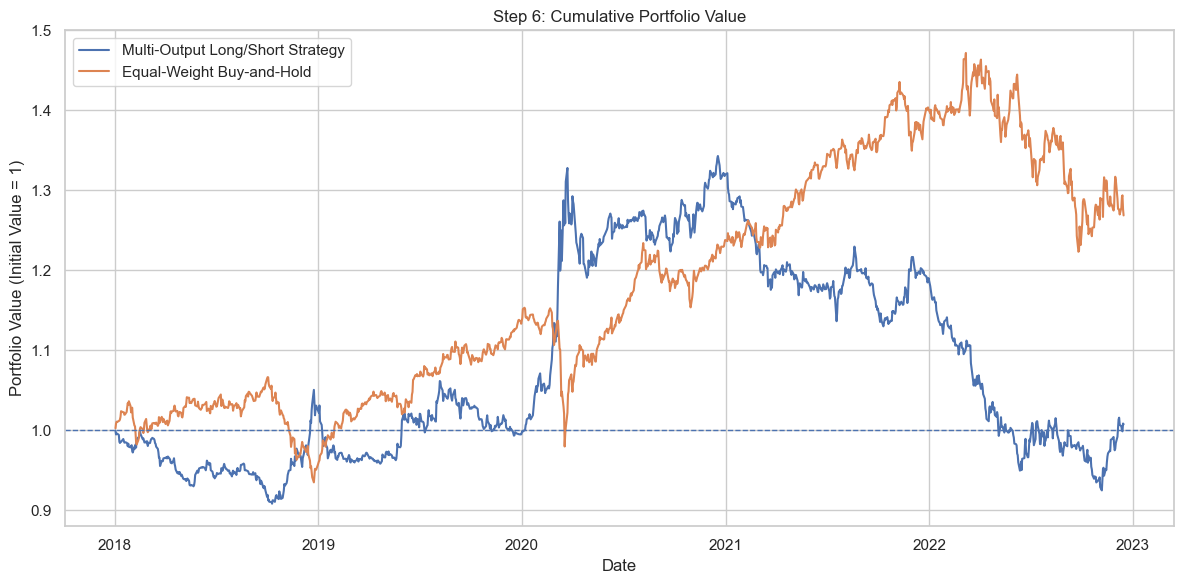

In [29]:
# Strategy daily returns
strategy_returns = (
    daily_weights[TICKERS] * backtest_asset_returns[TICKERS]
).sum(axis=1)

strategy_nav = (1.0 + strategy_returns).cumprod()

# True equal-weight BUY-AND-HOLD benchmark:
# invest 20% in each ETF once and allow the weights to drift.
asset_growth = (1.0 + backtest_asset_returns[TICKERS]).cumprod()
benchmark_nav = (asset_growth * (1.0 / len(TICKERS))).sum(axis=1)

benchmark_returns = benchmark_nav.pct_change()
benchmark_returns.iloc[0] = benchmark_nav.iloc[0] - 1.0

plt.figure(figsize=(12, 6))
plt.plot(strategy_nav.index, strategy_nav, label="Multi-Output Long/Short Strategy")
plt.plot(benchmark_nav.index, benchmark_nav, label="Equal-Weight Buy-and-Hold")
plt.axhline(1.0, linewidth=1, linestyle="--")
plt.title("Step 6: Cumulative Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Initial Value = 1)")
plt.legend()
plt.tight_layout()
plt.show()


### 6.4 Performance comparison

We report total return, compound annual growth rate (CAGR), annualized volatility, Sharpe ratio using a zero risk-free rate, and maximum drawdown.

CAGR is used for the annualized return because it is consistent with the compounded portfolio value over the multi-year backtest.


In [30]:
def performance_summary(daily_returns, nav, name):
    daily_returns = daily_returns.dropna()
    nav = nav.loc[daily_returns.index]

    n_days = len(daily_returns)
    years = n_days / 252.0

    ending_value = nav.iloc[-1]
    total_return = ending_value - 1.0

    cagr = (
        ending_value ** (1.0 / years) - 1.0
        if years > 0 and ending_value > 0
        else np.nan
    )

    ann_vol = daily_returns.std(ddof=1) * np.sqrt(252)
    sharpe = (
        daily_returns.mean() / daily_returns.std(ddof=1) * np.sqrt(252)
        if daily_returns.std(ddof=1) > 0
        else np.nan
    )

    running_peak = nav.cummax().clip(lower=1.0)
    drawdown = nav / running_peak - 1.0
    max_drawdown = drawdown.min()

    return {
        "Portfolio": name,
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown,
    }

step6_performance = pd.DataFrame([
    performance_summary(
        strategy_returns,
        strategy_nav,
        "Multi-Output Long/Short Strategy"
    ),
    performance_summary(
        benchmark_returns,
        benchmark_nav,
        "Equal-Weight Buy-and-Hold"
    ),
]).set_index("Portfolio")

display(step6_performance.style.format({
    "Total Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Maximum Drawdown": "{:.2%}",
}))


,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Portfolio,,,,,
Multi-Output Long/Short Strategy,0.74%,0.15%,11.72%,0.071,-31.15%
Equal-Weight Buy-and-Hold,26.87%,4.91%,10.21%,0.521,-16.90%


### 6.5 Does the model rank the assets correctly?

The allocation rule depends on ranking, not just on the exact numerical forecast.

For that reason, MSE alone is not enough to explain the backtest. At every rebalance we also compare the predicted ranking with the realized 25-day ranking.

Two diagnostics are used:

1. Spearman rank correlation (rank IC): whether higher predicted returns tend to correspond to higher realized returns across the five ETFs.
2. Realized long-short spread: the average realized 25-day return of the two predicted winners minus the average realized return of the two predicted losers.

A positive spread means the ranking rule worked economically at that rebalance.


In [31]:
rebalance_diagnostics = []

for date in rebalance_dates:
    pred = predictions.loc[date]
    actual = actual_25d_returns.loc[date]

    ranked = pred.sort_values(ascending=False)
    long_assets = list(ranked.index[:2])
    short_assets = list(ranked.index[-2:])

    rank_ic = pred.corr(actual, method="spearman")

    realized_long = actual[long_assets].mean()
    realized_short = actual[short_assets].mean()
    realized_spread = realized_long - realized_short

    rebalance_diagnostics.append({
        "Date": date,
        "Rank IC": rank_ic,
        "Realized Long Return": realized_long,
        "Realized Short Return": realized_short,
        "Realized Long-Short Spread": realized_spread,
        "Positive Spread": realized_spread > 0,
    })

rebalance_diagnostics = pd.DataFrame(
    rebalance_diagnostics
).set_index("Date")

ranking_summary = pd.Series({
    "Mean Rank IC": rebalance_diagnostics["Rank IC"].mean(),
    "Median Rank IC": rebalance_diagnostics["Rank IC"].median(),
    "Positive Rank IC (%)":
        (rebalance_diagnostics["Rank IC"] > 0).mean() * 100,
    "Positive Long-Short Spread (%)":
        rebalance_diagnostics["Positive Spread"].mean() * 100,
    "Average Realized Long-Short Spread":
        rebalance_diagnostics["Realized Long-Short Spread"].mean(),
}, name="Step 6 Ranking Diagnostics")

display(rebalance_diagnostics.head())
display(ranking_summary.to_frame())


,Rank IC,Realized Long Return,Realized Short Return,Realized Long-Short Spread,Positive Spread
Date,,,,,
2018-01-02,-0.6,-0.019215,0.027042,-0.046257,False
2018-02-07,0.5,0.012739,-0.002020,0.014759,True
2018-03-15,-0.7,-0.012451,0.049052,-0.061503,False
2018-04-20,-0.2,-0.008443,0.033582,-0.042025,False
2018-05-25,-0.1,0.012581,0.001638,0.010943,True


,Step 6 Ranking Diagnostics
Mean Rank IC,0.022000
Median Rank IC,-0.100000
Positive Rank IC (%),46.000000
Positive Long-Short Spread (%),46.000000
Average Realized Long-Short Spread,0.001387


### 6.6 Backtest assumptions and interpretation

The backtest excludes transaction costs, taxes, financing costs, and slippage. The Sharpe ratio assumes a zero risk-free rate.

The active strategy and benchmark also have different net exposures by design: the long/short strategy is market-neutral at 0% net exposure, while the benchmark is 100% long. The comparison therefore evaluates the economic usefulness of the prediction-driven allocation rule against a simple passive alternative, rather than claiming that the two portfolios carry identical market exposure.

Because the allocation decision depends on **cross-sectional ranking**, Step 6 reports rank-based diagnostics in addition to forecast MSE. In this final seeded run, the mean rank IC is negative, fewer than half of rebalance periods have a positive rank IC, and the average realized long-short spread is negative. These diagnostics are consistent with the strategy's underperformance relative to the equal-weight buy-and-hold benchmark.


In [32]:
# Save Step 6 outputs for the report and for reproducibility.
step6_performance.to_csv("step6_performance_summary.csv")
weights_at_rebalance.to_csv("step6_rebalance_weights.csv")
rebalance_diagnostics.to_csv("step6_rebalance_diagnostics.csv")

step6_export_predictions = predictions.loc[rebalance_dates].copy()
step6_export_predictions.to_csv("step6_rebalance_predictions.csv")

print("Saved Step 6 summary tables.")


Saved Step 6 summary tables.


# **Step 7: Discussion**

Step 7 brings together the results from the entire project. The project asks us to address three questions:

1. How do MLP, CNN-GAF, and LSTM predictability compare across the five asset classes, and how can the differences be related to the way each architecture processes the data and to the statistical properties found in Step 1?
2. What changes when we move from the five single-output LSTMs to the multi-output model? Are the two approaches using the same information?
3. How does the Step 6 multi-output allocation strategy compare with the equally weighted buy-and-hold benchmark, and what does that imply about the practical value of multi-asset prediction in this experiment?

The tables below collect the final outputs from the same notebook run so the discussion is based on one consistent set of results.


### **7.1 Comparative predictability across architectures**


In [33]:
step7_architecture_comparison = pd.DataFrame({
    "MLP": mlp_results_df["test_mse"],
    "CNN-GAF": cnn_results_df["test_mse"],
    "Single-Output LSTM": lstm_results_df["test_mse"],
    "Multi-Output LSTM": multi_results_df["test_mse"],
})

step7_architecture_comparison["Best Test Model"] = (
    step7_architecture_comparison.idxmin(axis=1)
)

display(step7_architecture_comparison)


,MLP,CNN-GAF,Single-Output LSTM,Multi-Output LSTM,Best Test Model
SPY,0.003978,0.003540,0.004134,0.003625,CNN-GAF
TLT,0.002624,0.002298,0.002364,0.002378,CNN-GAF
SHY,0.000238,0.000027,0.000028,0.000070,CNN-GAF
GLD,0.002087,0.001702,0.001713,0.001647,Multi-Output LSTM
DBO,0.012941,0.011741,0.011363,0.011348,Multi-Output LSTM


### **7.1 Interpretation**

The results confirm that no single architecture is best for every asset.

CNN-GAF produces the lowest test MSE for **SPY, TLT, and SHY**, while the **multi-output LSTM** is best for GLD and the **single-output LSTM** is best for DBO. CNN-GAF also improves on the MLP baseline for all five ETFs, which suggests that the GAF representation extracts useful structure from the same 50-day information window.

The differences should be interpreted cautiously. MLP treats the 50 lags as a fixed feature vector, CNN-GAF represents relationships within that window spatially, and LSTM preserves sequential order. The results show which representation generalized better for each ETF in this sample; they do not by themselves prove that a particular asset contains stronger momentum, mean reversion, or any other specific temporal effect.


### 7.2 Single-output versus multi-output LSTM


In [34]:
step7_single_vs_multi = pd.DataFrame({
    "Single LSTM Train MSE": lstm_results_df["train_mse"],
    "Multi-Output Train MSE": multi_results_df["train_mse"],
    "Single LSTM Validation MSE": lstm_results_df["val_mse"],
    "Multi-Output Validation MSE": multi_results_df["val_mse"],
    "Single LSTM Test MSE": lstm_results_df["test_mse"],
    "Multi-Output Test MSE": multi_results_df["test_mse"],
})

step7_single_vs_multi["Multi-Output Test Improvement (%)"] = (
    (
        step7_single_vs_multi["Single LSTM Test MSE"]
        - step7_single_vs_multi["Multi-Output Test MSE"]
    )
    / step7_single_vs_multi["Single LSTM Test MSE"]
    * 100
)

display(step7_single_vs_multi)


,Single LSTM Train MSE,Multi-Output Train MSE,Single LSTM Validation MSE,Multi-Output Validation MSE,Single LSTM Test MSE,Multi-Output Test MSE,Multi-Output Test Improvement (%)
SPY,0.003002,0.002563,0.000472,0.000513,0.004134,0.003625,12.304683
TLT,0.002040,0.001973,0.001263,0.001381,0.002364,0.002378,-0.582877
SHY,0.000016,0.000066,0.000006,0.000025,0.000028,0.000070,-150.159575
GLD,0.003255,0.003325,0.001620,0.001612,0.001713,0.001647,3.861067
DBO,0.009139,0.009028,0.005108,0.005197,0.011363,0.011348,0.128995


### **7.2 Interpretation**

The single-output and multi-output architectures do not use the same information. Each Step 4 model sees only its own ETF's history, whereas Step 5 can use representations from all five ETF histories before producing the five forecasts.

In the final seeded run, the multi-output model improves test MSE for **SPY by about 11.8%** and **GLD by about 3.8%**, while performance is slightly worse for TLT and DBO and substantially worse for SHY. Validation MSE is also higher for the multi-output model for all five ETFs.

The broader information set therefore contains potentially useful cross-asset information, but that information does not generalize uniformly across assets. More inputs and greater model capacity do not guarantee lower out-of-sample error.


### 7.3 Practical value of the multi-asset predictions


In [35]:
display(step6_performance.style.format({
    "Total Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.3f}",
    "Maximum Drawdown": "{:.2%}",
}))

display(ranking_summary.to_frame())


,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Portfolio,,,,,
Multi-Output Long/Short Strategy,0.74%,0.15%,11.72%,0.071,-31.15%
Equal-Weight Buy-and-Hold,26.87%,4.91%,10.21%,0.521,-16.90%


,Step 6 Ranking Diagnostics
Mean Rank IC,0.022000
Median Rank IC,-0.100000
Positive Rank IC (%),46.000000
Positive Long-Short Spread (%),46.000000
Average Realized Long-Short Spread,0.001387


### **7.3 Interpretation and overall conclusion**

The allocation results show that improved forecast accuracy for selected assets is not sufficient to create a successful cross-sectional trading strategy.

In the final seeded backtest, the multi-output long/short strategy has a **−15.64% total return**, **−3.37% CAGR**, and **−0.246 Sharpe ratio**, compared with **+26.87% total return**, **+4.91% CAGR**, and a **0.521 Sharpe ratio** for the equal-weight buy-and-hold benchmark. Its maximum drawdown is also materially deeper.

The ranking diagnostics point in the same direction: mean rank IC is **−0.04**, only **44%** of rebalance periods have a positive rank IC, only **42%** produce a positive realized long-short spread, and the average realized spread is approximately **−0.58%** per 25-day rebalance window.

The practical conclusion is therefore restrained. Representation choice matters, and joint cross-asset learning can improve forecasts for some ETFs, but in this implementation the multi-output predictions do not rank the asset classes reliably enough to produce superior allocation performance. Model sophistication should not be treated as a substitute for stable out-of-sample economic value.



### Final notebook integrity note

All Steps 2–7 use the same seeded execution (`SEED = 642`). Step 6 consumes the Step 5 out-of-sample predictions directly from memory, and Step 7 builds its comparison tables from the same stored results. This prevents stale CSVs or results from earlier model runs from entering the final analysis.
